Import the libraries.

In [1]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

Load the premade dataset from sklearn.datasets.

In [2]:
x,y = load_diabetes(return_X_y=True)
x.shape,y.shape

((442, 10), (442,))

Train test split.

In [3]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((331, 10), (111, 10), (331,), (111,))

Apply ridge regession on train data and print the r2 score, co-efficient and intercept values.

In [4]:
from sklearn.linear_model import Ridge
model = Ridge(alpha=1.0, solver='cholesky')
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(r2_score(y_test,y_pred))
print(model.coef_)
print(model.intercept_)

0.43840029731424435
[  50.55201232  -67.7222237   278.30122846  197.62263845   -6.24583645
  -26.22672623 -151.39433086  120.3233589   215.85446319  101.75577423]
152.51411105005687


Make our own Rigde regression class same as self made regression same as sklearn's one.

In [5]:
class SelfMadeRidge:
    def __init__(self,alpha=1.0):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self,x_train,y_train):
        x_train = np.hstack((np.ones((x_train.shape[0],1)),x_train))
        identity = np.eye(x_train.shape[1])
        identity[0,0] = 0
        beta = np.linalg.inv(x_train.T.dot(x_train) + self.alpha*identity).dot(x_train.T).dot(y_train)
        self.intercept_ = beta[0]
        self.coef_ = beta[1:]

    def predict(self,x):
        return np.dot(x_test,self.coef_) + self.intercept_
        

Apply self made Ridge regression on train data.

In [6]:
reg = SelfMadeRidge(alpha=0.10)
reg.fit(x_train,y_train)
y_pred = reg.predict(x_test)
r2_score(y_test,y_pred), reg.coef_, reg.intercept_

(0.4918270736855388,
 array([  52.86608707, -200.50867028,  493.95917239,  339.27983427,
        -118.0630055 ,  -80.91079472, -215.28052241,  153.41456749,
         365.68204531,   62.42262866]),
 np.float64(151.73066313714745))

Make a new regression dataset.

In [7]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

Plot the points.

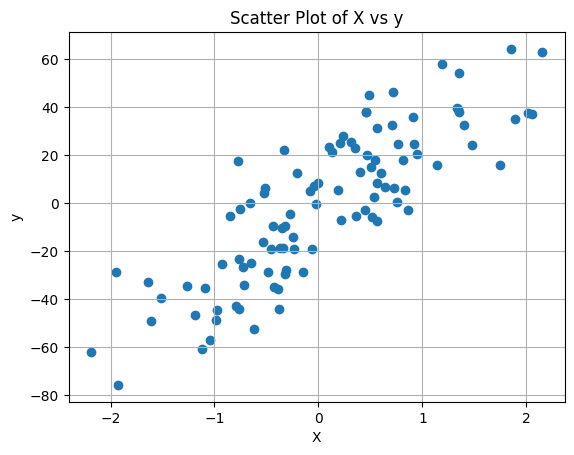

In [8]:
plt.scatter(X,y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter Plot of X vs y')
plt.grid()
plt.show()

Train the regression model on newly made data and print co-efficient and intercept values.

In [9]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X,y)
print("Linear Regression Coefficient:", lr.coef_)
print("Linear Regression Intercept:", lr.intercept_)

Linear Regression Coefficient: [27.82809103]
Linear Regression Intercept: -2.29474455867698


Apply ridge regression for different values of alpha.

In [10]:
from sklearn.linear_model import Ridge
model = Ridge(alpha=1.0)
model.fit(X,y)
print("Ridge Regression Coefficient:", model.coef_)
print("Ridge Regression Intercept:", model.intercept_)

Ridge Regression Coefficient: [27.51130507]
Ridge Regression Intercept: -2.276241917183367


In [11]:
rr1 = Ridge(alpha=100)
rr1.fit(X,y)
print("Ridge Regression with alpha=100 Coefficient:", rr1.coef_)
print("Ridge Regression with alpha=100 Intercept:", rr1.intercept_)

Ridge Regression with alpha=100 Coefficient: [12.93442104]
Ridge Regression with alpha=100 Intercept: -1.4248441496033308


Plot the best fit line for different values of alpha.

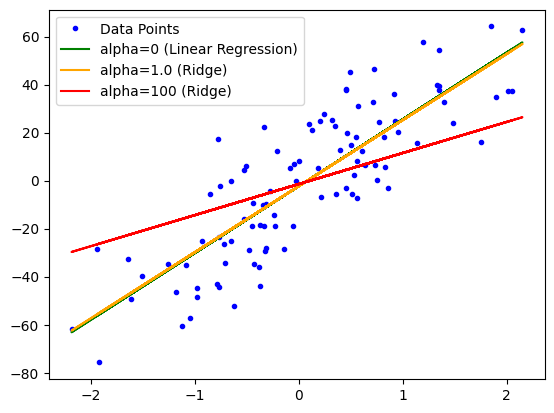

In [12]:
plt.plot(X, y, 'b.', label='Data Points')

plt.plot(X, lr.predict(X), color='green', label='alpha=0 (Linear Regression)')
plt.plot(X, model.predict(X), color='orange', label='alpha=1.0 (Ridge)')
plt.plot(X, rr1.predict(X), color='red', label='alpha=100 (Ridge)')

plt.legend()
plt.show()

Self made linear regression function.


In [13]:
def linear_regression(X,y,alpha=1):
    x_mean = X.mean()
    y_mean = y.mean()
    
    num = 0
    den = 0
    
    for i in range(X.shape[0]):
        num = num + (y[i] - y_mean) * (X[i] - x_mean)
        den = den + (X[i] - x_mean) * (X[i] - x_mean)
        
    m = num/(den + alpha)
    b = y_mean - m*x_mean
        
    return m,b
class MeraRidge:
    
    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        
        num = 0
        den = 0
        
        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean())*(X_train[i] - X_train.mean())
        
        self.m = num/(den + self.alpha)
        self.b = y_train.mean() - (self.m*X_train.mean())
        print(self.m,self.b)
    
    def predict(X_test):
        pass

In [14]:
reg = MeraRidge(alpha=100)
reg.fit(X,y)

[12.93442104] [-1.42484415]
